In [ ]:
# from statistics import correlation

In [ ]:
# Check if data holds duplicate values.

In [ ]:
# Fill missing numerical values with 0

In [ ]:
# dropping columns that are not useful

In [ ]:
# type of logistic regression

In [ ]:
from statistics import correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

#Read and load data
df = pd.read_csv("hotel_bookings.csv")
#Display data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


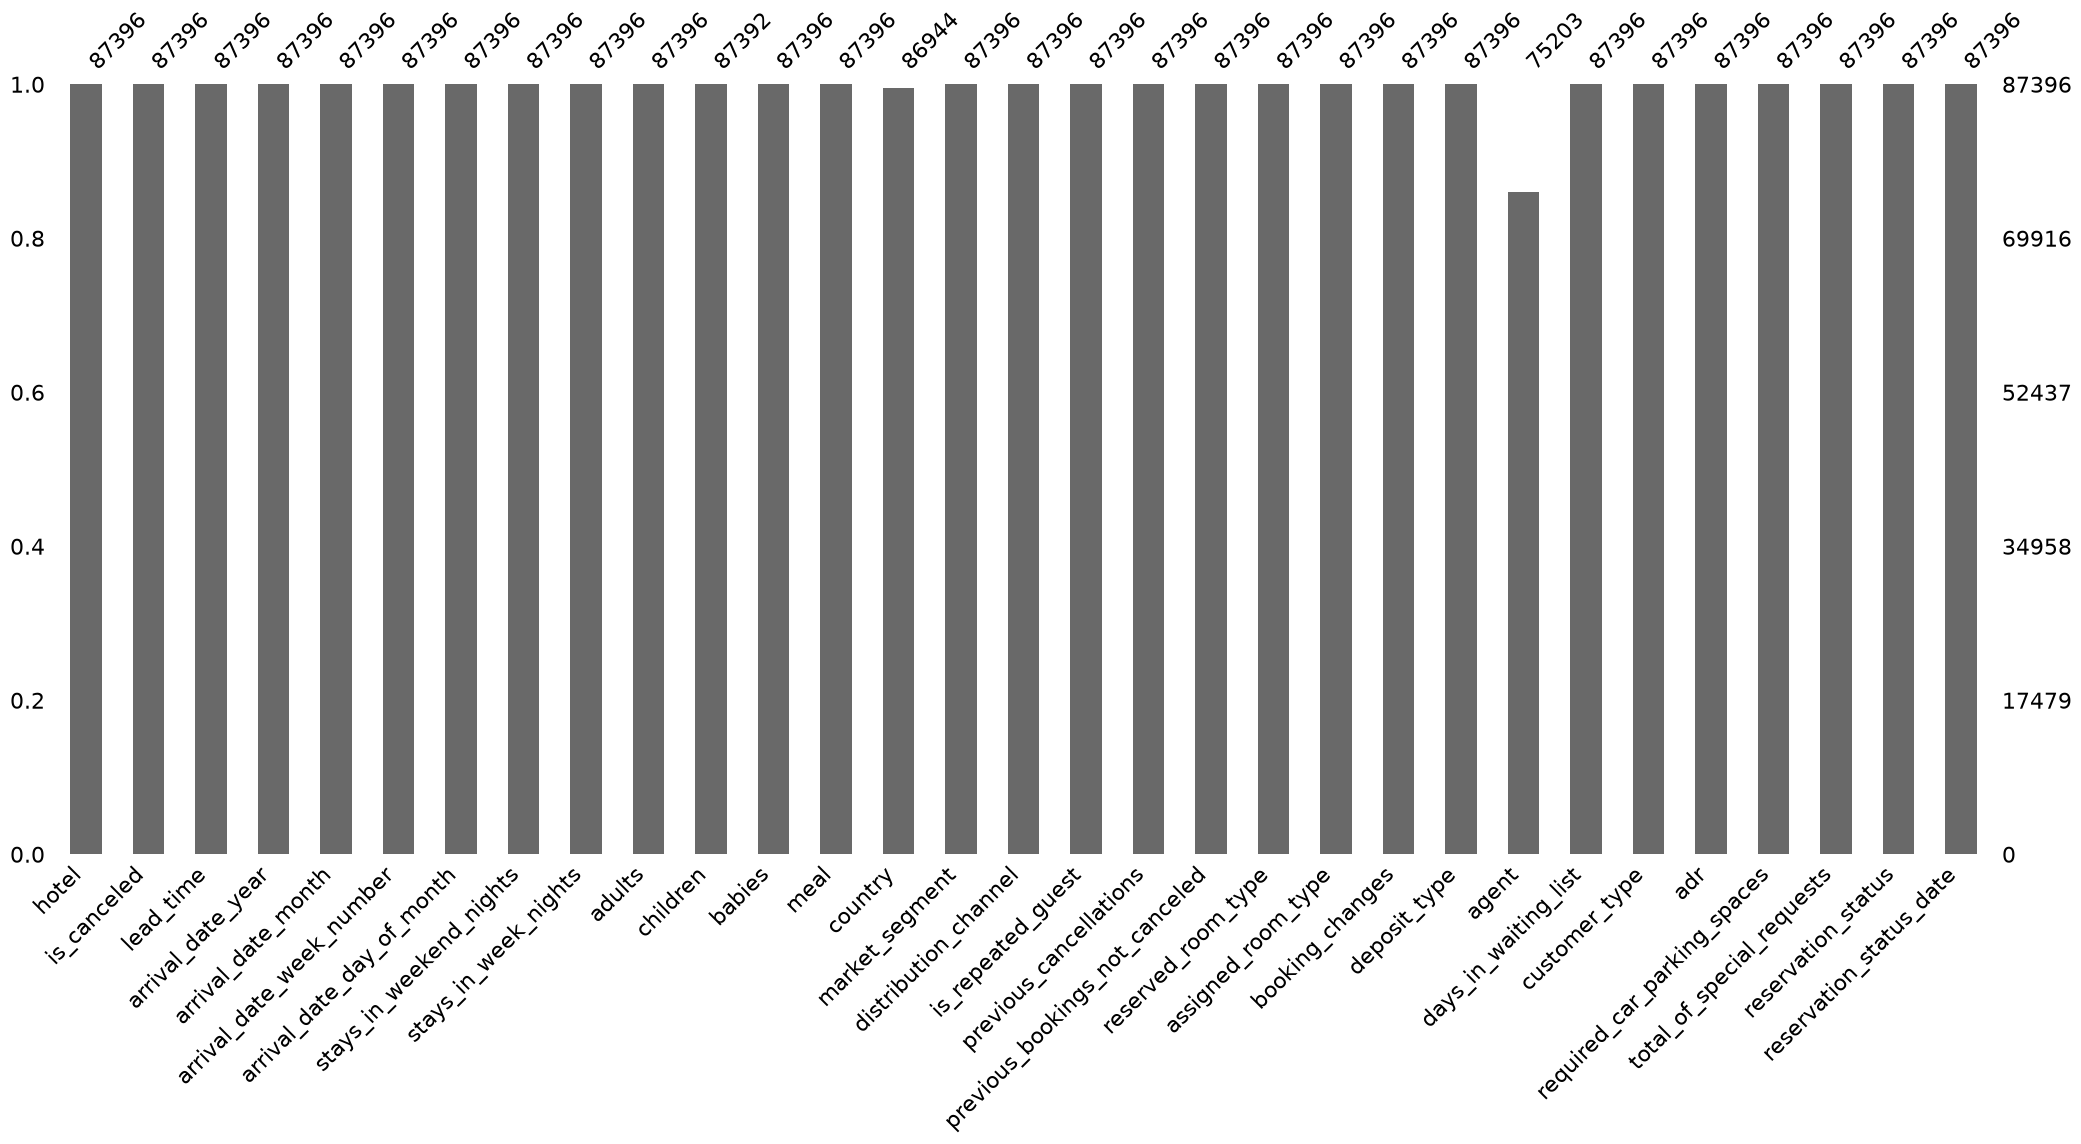

In [ ]:
#Check if data holds duplicate values.
df.duplicated().any()
#Drop Duplicate entries 
df = df.drop_duplicates()# will keep first row and others consider as duplicate
null =100 *(df.isna().sum() /df.shape[0])
null
df.drop('company',axis=1, inplace = True)
import missingno as msno
msno.bar(df)
plt.show()

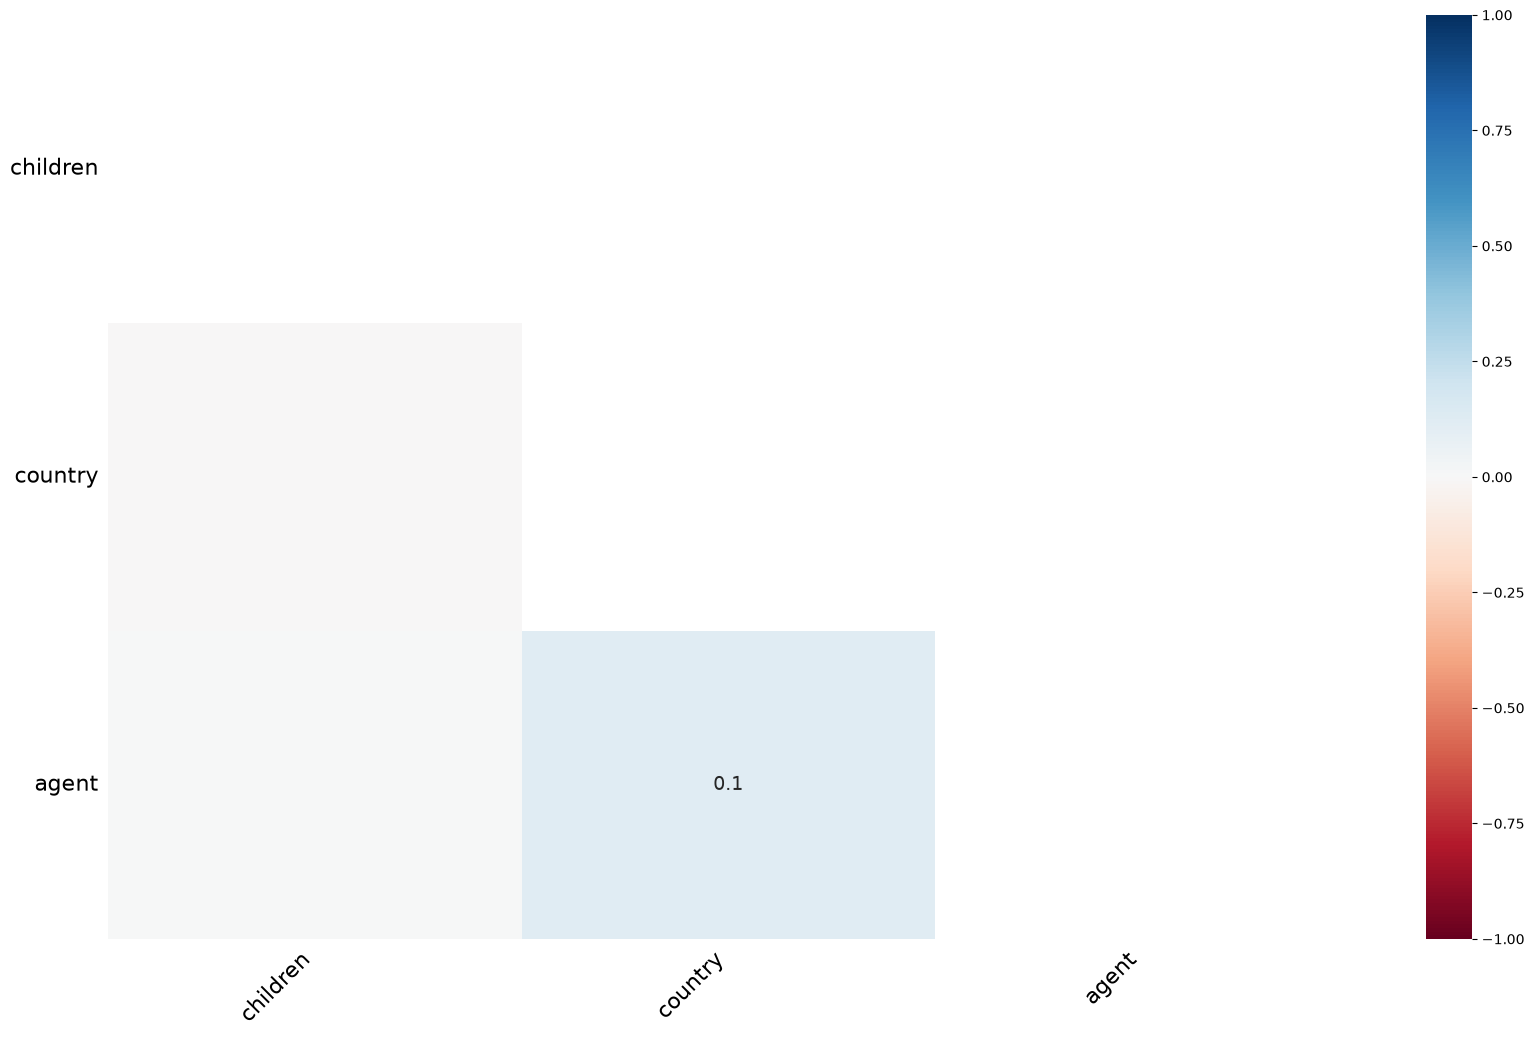

In [ ]:
msno.heatmap(df)
# Fill missing numerical values with 0
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

# Fill missing text/categorical values with 'Unknown'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')
df['is_canceled'].value_counts()
filter = (df.children == 0) & (df.adults == 0) & (df.babies == 0)
df[filter]
df = df[~filter]
df
guest_city = df[df['is_canceled'] == 0]['country'].value_counts().reset_index()
guest_city.columns = ['Country', 'No of guests']
guest_city

guest_city = df[df['is_canceled'] == 0]['country'].value_counts().reset_index()
guest_city.columns = ['Country', 'No of guests']
guest_city

basemap = folium.Map()
guests_map = px.choropleth(guest_city, locations = guest_city['Country'],
                           color = guest_city['No of guests'], hover_name = guest_city['Country'])
guests_map.show()

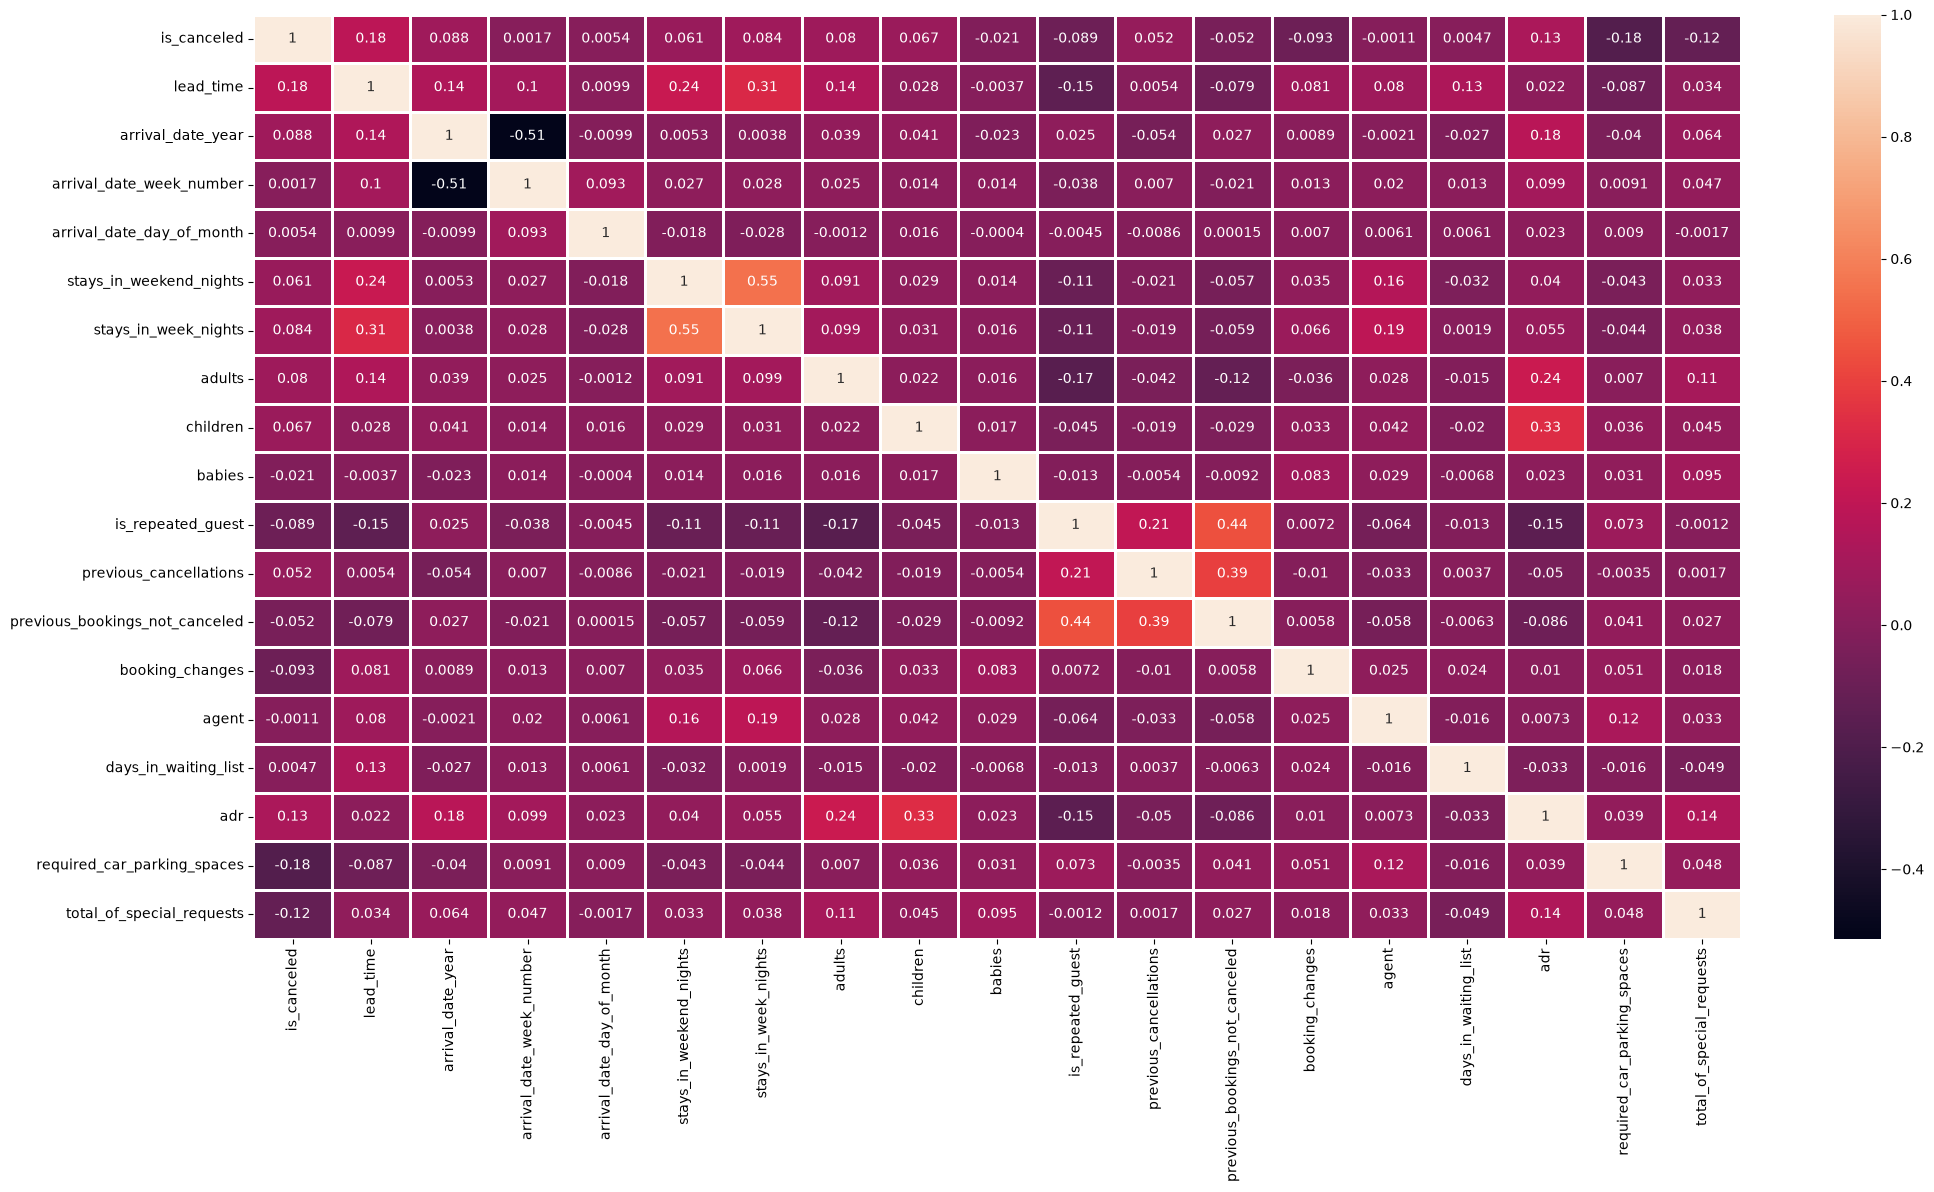

is_canceled                       1.000000
lead_time                         0.184515
required_car_parking_spaces       0.184456
adr                               0.127233
total_of_special_requests         0.120794
booking_changes                   0.093236
is_repeated_guest                 0.088764
arrival_date_year                 0.088020
stays_in_week_nights              0.084159
adults                            0.080271
children                          0.067182
stays_in_weekend_nights           0.060992
previous_bookings_not_canceled    0.052178
previous_cancellations            0.051501
babies                            0.020627
arrival_date_day_of_month         0.005449
days_in_waiting_list              0.004710
arrival_date_week_number          0.001691
agent                             0.001145
Name: is_canceled, dtype: float64

In [ ]:
data_resort = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)]
data_city = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0)]
resort_hotel = data_resort.groupby(['arrival_date_month'])['adr'].mean().reset_index()
resort_hotel

city_hotel=data_city.groupby(['arrival_date_month'])['adr'].mean().reset_index()
city_hotel

import sort_dataframeby_monthorweek as sd

def sort_month(df, column_name):
    return sd.Sort_Dataframeby_Month(df, column_name)

plt.figure(figsize = (24, 12))

#corr = df.corr()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot = True, linewidths = 1)
plt.show()
#correlation = df.corr()['is_canceled'].abs().sort_values(ascending = False)
correlation = df.corr(numeric_only=True)['is_canceled'].abs().sort_values(ascending = False)
correlation

In [ ]:
# dropping columns that are not useful
# 1. Drop useless columns from df
useless_col = ['days_in_waiting_list', 'arrival_date_year', 'arrival_date_month', 'assigned_room_type', 'booking_changes', 'reservation_status', 'country']

df.drop(columns=useless_col, inplace=True, errors='ignore')

# 2. Explicitly define the categorical columns we want to work with (Bulletproof method)
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 
            'reserved_room_type', 'deposit_type', 'customer_type', 'reservation_status_date']

# Keep only columns that actually exist in df
cat_cols = [col for col in cat_cols if col in df.columns]
cat_df = df[cat_cols].copy()

# 3. Handle Dates
if 'reservation_status_date' in cat_df.columns:
    cat_df['reservation_status_date'] = pd.to_datetime(cat_df['reservation_status_date'])
    cat_df['year'] = cat_df['reservation_status_date'].dt.year
    cat_df['month'] = cat_df['reservation_status_date'].dt.month
    cat_df['day'] = cat_df['reservation_status_date'].dt.day
    cat_df.drop(['reservation_status_date'], axis=1, inplace=True, errors='ignore')

# 4. Safely encode variables using .replace() (Works regardless of dtype)
cat_df['hotel'] = cat_df['hotel'].replace({'Resort Hotel' : 0, 'City Hotel' : 1})
cat_df['meal'] = cat_df['meal'].replace({'BB' : 0, 'FB': 1, 'HB': 2, 'SC': 3, 'Undefined': 4})
cat_df['market_segment'] = cat_df['market_segment'].replace({
    'Direct': 0, 'Corporate': 1, 'Online TA': 2, 'Offline TA/TO': 3,
    'Complementary': 4, 'Groups': 5, 'Undefined': 6, 'Aviation': 7})
cat_df['distribution_channel'] = cat_df['distribution_channel'].replace({
    'Direct': 0, 'Corporate': 1, 'TA/TO': 2, 'Undefined': 3, 'GDS': 4})
cat_df['reserved_room_type'] = cat_df['reserved_room_type'].replace({
    'C': 0, 'A': 1, 'D': 2, 'E': 3, 'G': 4, 'F': 5, 'H': 6, 'L': 7, 'B': 8})
cat_df['deposit_type'] = cat_df['deposit_type'].replace({'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2})
cat_df['customer_type'] = cat_df['customer_type'].replace({'Transient': 0, 'Contract': 1, 'Transient-Party': 2, 'Group': 3})

if 'year' in cat_df.columns:
    cat_df['year'] = cat_df['year'].replace({2014: 0, 2015: 1, 2016: 2, 2017: 3})

# FAIL-SAFE: Force all columns to numeric. 
# Any rogue unmapped text will become NaN, which we then fill with 0.
cat_df = cat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
cat_df.head()

# Drop categorical columns from numeric dataframe
num_df = df.drop(columns=cat_cols)

# Drop target variable 'is_canceled'
num_df.drop(columns=['is_canceled'], inplace=True, errors='ignore')

# Apply log transformations
num_df['lead_time'] = np.log(num_df['lead_time'] + 1)
num_df['arrival_date_week_number'] = np.log(num_df['arrival_date_week_number'] + 1)
num_df['arrival_date_day_of_month'] = np.log(num_df['arrival_date_day_of_month'] + 1)
num_df['agent'] = np.log(num_df['agent'] + 1)
num_df['adr'] = np.log(num_df['adr'] + 1)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X = pd.concat([cat_df, num_df], axis = 1)
y = df['is_canceled']

X = X.fillna(0)
# Check which columns are still objects/strings
print("Non-numeric columns remaining:", X.select_dtypes(include=['object']).columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

Non-numeric columns remaining: []


In [ ]:
#type of logistic regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
conf = confusion_matrix(y_test, y_pred_lr)
clf_report = classification_report(y_test, y_pred_lr)

print(f"Accuracy Score of Logistic Regression is : {acc_lr}")
print(f"Confusion Matrix : \n{conf}")
print(f"Classification Report : \n{clf_report}")

##%%
#KNN Classifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
conf = confusion_matrix(y_test, y_pred_knn)
clf_report = classification_report(y_test, y_pred_knn)

print(f"Accuracy Score of KNN is : {acc_knn}")
print(f"Confusion Matrix : n{conf}")
print(f"Classification Report : n{clf_report}")

##%%
##DECISION TREE CLASSIFIER ALGORITHM
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred_dtc = dtc.predict(X_test)
acc_dtc = accuracy_score(y_test, y_pred_dtc)
conf = confusion_matrix(y_test, y_pred_dtc)
clf_report = classification_report(y_test, y_pred_dtc)
print(f"Accuracy Score of Decision Tree is : {acc_dtc}")
print(f"Confusion Matrix : n{conf}")
print(f"Classification Report : n{clf_report}")

##%%
######## random forest classifier
rd_clf = RandomForestClassifier()
rd_clf.fit(X_train, y_train)

y_pred_rd_clf = rd_clf.predict(X_test)

acc_rd_clf = accuracy_score(y_test, y_pred_rd_clf)
conf = confusion_matrix(y_test, y_pred_rd_clf)
clf_report = classification_report(y_test, y_pred_rd_clf)

print(f"Accuracy Score of Random Forest is : {acc_rd_clf}")
print(f"Confusion Matrix : n{conf}")
print(f"Classification Report : n{clf_report}")

Accuracy Score of Logistic Regression is : 0.8012533914173259
Confusion Matrix : 
[[18102   922]
 [ 4279  2866]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.81      0.95      0.87     19024
           1       0.76      0.40      0.52      7145

    accuracy                           0.80     26169
   macro avg       0.78      0.68      0.70     26169
weighted avg       0.79      0.80      0.78     26169

Accuracy Score of KNN is : 0.8545225266536742
Confusion Matrix : n[[18386   638]
 [ 3169  3976]]
Classification Report : n              precision    recall  f1-score   support

           0       0.85      0.97      0.91     19024
           1       0.86      0.56      0.68      7145

    accuracy                           0.85     26169
   macro avg       0.86      0.76      0.79     26169
weighted avg       0.86      0.85      0.84     26169

Accuracy Score of Decision Tree is : 0.927777140891895
Confusion Matrix : n[[18097   9